<a href="https://colab.research.google.com/github/RuanCarlosDaSilvaLima/Estudos-Inteligencia-artificial/blob/main/lista_de_exercicios_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

instalando bibliotecas

In [1]:
!pip install torch scikit-learn matplotlib pandas

importando as bibliotecas

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

Verificando o PyTorch e a GPU

In [3]:
print("Versão do PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

Versão do PyTorch: 2.11.0+cpu
GPU disponível: False


Definindo o dispositivo

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


Carregando a base da Iris

In [5]:
iris = load_iris()

X = iris.data
y = iris.target
nomes = iris.target_names

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Espécies:", nomes)

Formato de X: (150, 4)
Formato de y: (150,)
Espécies: ['setosa' 'versicolor' 'virginica']


Visualizando os dados com DataFrame

In [6]:
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["especie"] = [nomes[i] for i in y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Celecionando as caracteristicas especificas da petala. Largura e comprimento

In [7]:
X2 = X[:, 2:4]

print("Formato de X2:", X2.shape)
print(X2[:5])

Formato de X2: (150, 2)
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]


Padronizando os dados na ordem de media, desvio e Z-score

In [8]:
media = X2.mean(axis=0)
desvio = X2.std(axis=0)

X2 = (X2 - media) / desvio

print("Média:", media)
print("Desvio padrão:", desvio)

Média: [3.758      1.19933333]
Desvio padrão: [1.75940407 0.75969263]


In [9]:
X2_t = torch.tensor(
    X2,
    dtype=torch.float32,
    device=device
)

y_t = torch.tensor(
    y,
    dtype=torch.long,
    device=device
)

print("X2_t:", X2_t.shape)
print("y_t:", y_t.shape)
print("Device:", X2_t.device)

X2_t: torch.Size([150, 2])
y_t: torch.Size([150])
Device: cpu


Separando os dados 80% para treino e 20% para teste

In [10]:
torch.manual_seed(42)

n = X2_t.shape[0]

indices = torch.randperm(n, device=device)

n_treino = int(0.8 * n)

indices_treino = indices[:n_treino]
indices_teste = indices[n_treino:]

X_train = X2_t[indices_treino]
y_train = y_t[indices_treino]

X_test = X2_t[indices_teste]
y_test = y_t[indices_teste]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([120, 2])
y_train: torch.Size([120])
X_test: torch.Size([30, 2])
y_test: torch.Size([30])


criando a função distancia

In [11]:
def calcular_distancias(X_test, X_train):
    """
    Calcula a distância euclidiana entre cada ponto
    de teste e cada ponto de treinamento.
    """

    distancias = torch.cdist(X_test, X_train)

    return distancias

testando a função distancia

In [12]:
distancias = calcular_distancias(X_test, X_train)

print("Formato da matriz de distâncias:", distancias.shape)

Formato da matriz de distâncias: torch.Size([30, 120])


Implementando o k-NN

In [13]:
def knn_predict(X_train, y_train, X_test, k=5):
    distancias = torch.cdist(X_test, X_train)

    _, indices_vizinhos = torch.topk(
        distancias,
        k=k,
        largest=False
    )

    labels_vizinhos = y_train[indices_vizinhos]

    predicoes = torch.mode(labels_vizinhos, dim=1).values

    return predicoes

executando a função

In [14]:
predicoes = knn_predict(
    X_train,
    y_train,
    X_test,
    k=5
)

print("Predições:", predicoes)
print("Rótulos reais:", y_test)

Predições: tensor([1, 2, 2, 1, 1, 1, 2, 1, 0, 0, 2, 0, 1, 0, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2,
        1, 0, 2, 2, 0, 2])
Rótulos reais: tensor([1, 2, 2, 1, 1, 1, 2, 1, 0, 0, 2, 0, 2, 0, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2,
        1, 0, 2, 2, 0, 2])


Calculando a acurácia

In [15]:
acuracia = (predicoes == y_test).float().mean()

print(f"Acurácia do k-NN (k=5): {acuracia.item():.4f}")

Acurácia do k-NN (k=5): 0.9333


Testar para os diferentes valores de k = [1, 3, 5, 7, 9]

In [16]:
valores_k = [1, 3, 5, 7, 9]

resultados_knn = []

for k in valores_k:
    predicoes = knn_predict(
        X_train,
        y_train,
        X_test,
        k=k
    )

    acuracia = (predicoes == y_test).float().mean().item()

    resultados_knn.append({
        "k": k,
        "Acurácia": acuracia
    })

tabela_knn = pd.DataFrame(resultados_knn)

tabela_knn

,k,Acurácia
0,1,0.900000
1,3,0.933333
2,5,0.933333
3,7,0.933333
4,9,0.933333


Descobrindo o melhor k

In [17]:
melhor_resultado = tabela_knn.loc[
    tabela_knn["Acurácia"].idxmax()
]

print("Melhor k:", int(melhor_resultado["k"]))
print(f"Melhor acurácia: {melhor_resultado['Acurácia']:.4f}")

Melhor k: 3
Melhor acurácia: 0.9333


Gerando um grafico para melhor vizualização

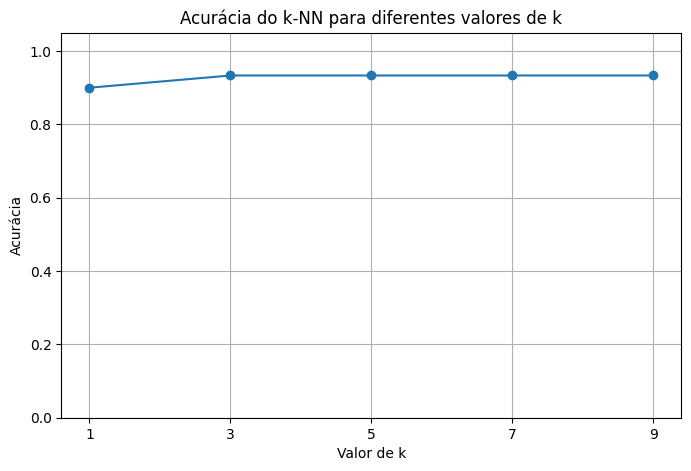

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabela_knn["k"],
    tabela_knn["Acurácia"],
    marker="o"
)

plt.xlabel("Valor de k")
plt.ylabel("Acurácia")
plt.title("Acurácia do k-NN para diferentes valores de k")
plt.xticks(valores_k)
plt.ylim(0, 1.05)
plt.grid(True)

plt.show()

Criando a região de decisão do k-NN

In [19]:
melhor_k = int(melhor_resultado["k"])

print("Usando k =", melhor_k)

Usando k = 3


Criando a grade 2D

In [20]:
x_min = X2[:, 0].min() - 0.5
x_max = X2[:, 0].max() + 0.5

y_min = X2[:, 1].min() - 0.5
y_max = X2[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grade = np.c_[xx.ravel(), yy.ravel()]

grade_t = torch.tensor(
    grade,
    dtype=torch.float32,
    device=device
)

print("Quantidade de pontos da grade:", grade_t.shape[0])

Quantidade de pontos da grade: 90000


Classificando a grade com o uso da função knn_predict()

In [21]:
predicoes_grade = knn_predict(
    X_train,
    y_train,
    grade_t,
    k=melhor_k
)

Z = predicoes_grade.cpu().numpy().reshape(xx.shape)

print("Formato da matriz de classificação:", Z.shape)

Formato da matriz de classificação: (300, 300)


Plotando a região de decisão

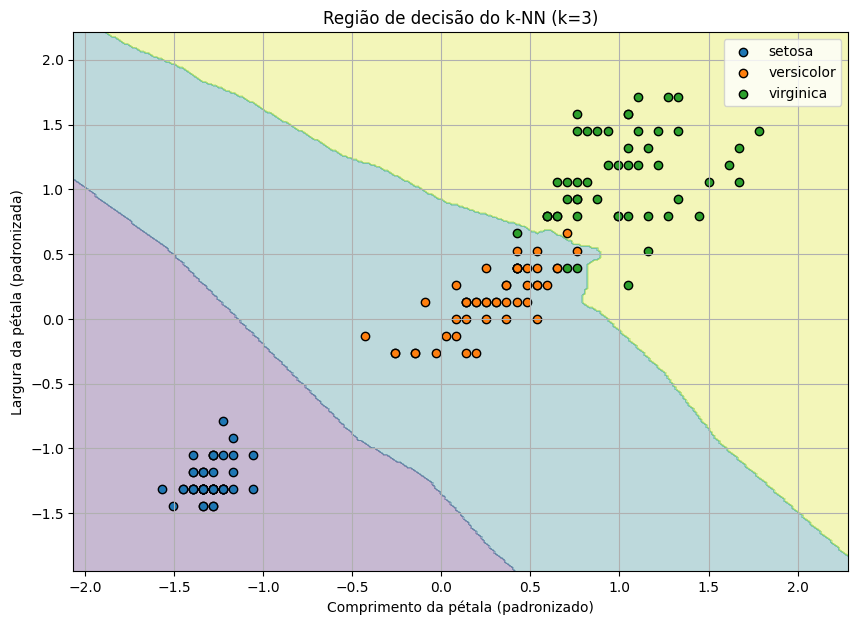

In [22]:
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

for classe in range(3):
    pontos = X2[y == classe]

    plt.scatter(
        pontos[:, 0],
        pontos[:, 1],
        label=nomes[classe],
        edgecolors="black"
    )

plt.xlabel("Comprimento da pétala (padronizado)")
plt.ylabel("Largura da pétala (padronizada)")
plt.title(f"Região de decisão do k-NN (k={melhor_k})")
plt.legend()
plt.grid(True)

plt.show()

Exercicio 2


Inicializando os 3 centroides

In [23]:
k = 3

torch.manual_seed(42)

indices_centroides = torch.randperm(
    X2_t.shape[0],
    device=device
)[:k]

centroides = X2_t[indices_centroides].clone()

print("Centroides iniciais:")
print(centroides)

Centroides iniciais:
tensor([[-1.3971e+00, -1.3154e+00],
        [ 2.5122e-01,  8.7755e-04],
        [-1.2266e+00, -1.3154e+00]])


Atribuindo cada ponto ao centroide mais próximo

In [24]:
distancias = torch.cdist(X2_t, centroides)

print("Formato das distâncias:", distancias.shape)

Formato das distâncias: torch.Size([150, 3])


In [25]:
clusters = torch.argmin(distancias, dim=1)

print("Clusters:")
print(clusters)

print("\nQuantidade de pontos em cada cluster:")

for i in range(k):
    quantidade = (clusters == i).sum().item()
    print(f"Cluster {i}: {quantidade} pontos")

Clusters:
tensor([0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2,
        2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0,
        2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1])

Quantidade de pontos em cada cluster:
Cluster 0: 24 pontos
Cluster 1: 100 pontos
Cluster 2: 26 pontos


Atualizando os Centroides

In [26]:
novos_centroides = torch.zeros_like(centroides)

for i in range(k):
    pontos_cluster = X2_t[clusters == i]

    if pontos_cluster.shape[0] > 0:
        novos_centroides[i] = pontos_cluster.mean(dim=0)
    else:
        novos_centroides[i] = centroides[i]

print("Centroides antigos:")
print(centroides)

print("\nNovos centroides:")
print(novos_centroides)

Centroides antigos:
tensor([[-1.3971e+00, -1.3154e+00],
        [ 2.5122e-01,  8.7755e-04],
        [-1.2266e+00, -1.3154e+00]])

Novos centroides:
tensor([[-1.3829, -1.2935],
        [ 0.6525,  0.6274],
        [-1.2331, -1.2193]])


Verificando a diferença dos centroides

In [27]:
diferenca = torch.norm(
    novos_centroides - centroides
)

print("Diferença entre os centroides:", diferenca.item())

Diferença entre os centroides: 0.7507247924804688


Substituindo os centroides pelos novos

In [28]:
centroides = novos_centroides.clone()

print("Centroides atualizados:")
print(centroides)

Centroides atualizados:
tensor([[-1.3829, -1.2935],
        [ 0.6525,  0.6274],
        [-1.2331, -1.2193]])


Implementando o k-Means completo

In [29]:
def kmeans(X, k, max_iter=100, tol=1e-4):
    indices = torch.randperm(
        X.shape[0],
        device=X.device
    )[:k]

    centroides = X[indices].clone()

    historico_inercia = []

    for iteracao in range(max_iter):
        distancias = torch.cdist(X, centroides)

        clusters = torch.argmin(
            distancias,
            dim=1
        )
        distancias_minimas = distancias[
            torch.arange(X.shape[0], device=X.device),
            clusters
        ]

        inercia = torch.sum(
            distancias_minimas ** 2
        )

        historico_inercia.append(
            inercia.item()
        )

        novos_centroides = torch.zeros_like(
            centroides
        )

        for i in range(k):

            pontos_cluster = X[
                clusters == i
            ]

            if pontos_cluster.shape[0] > 0:
                novos_centroides[i] = pontos_cluster.mean(
                    dim=0
                )
            else:
                novos_centroides[i] = centroides[i]

        diferenca = torch.norm(
            novos_centroides - centroides
        )

        centroides = novos_centroides

        if diferenca < tol:
            print(
                f"Convergência alcançada na iteração {iteracao + 1}"
            )
            break

    return clusters, centroides, historico_inercia

Executando o k-Means

In [30]:
torch.manual_seed(42)

clusters_kmeans, centroides_finais, historico_inercia = kmeans(
    X2_t,
    k=3
)

print("\nCentroides finais:")
print(centroides_finais)

print("\nQuantidade de pontos por cluster:")

for i in range(3):
    quantidade = (clusters_kmeans == i).sum().item()
    print(f"Cluster {i}: {quantidade} pontos")

Convergência alcançada na iteração 11

Centroides finais:
tensor([[-1.3050, -1.2549],
        [ 1.0280,  1.1280],
        [ 0.3059,  0.1654]])

Quantidade de pontos por cluster:
Cluster 0: 50 pontos
Cluster 1: 48 pontos
Cluster 2: 52 pontos


Visualizando a inércia

In [31]:
print("Inércia por iteração:")

for i, valor in enumerate(historico_inercia):
    print(f"Iteração {i + 1}: {valor:.4f}")

Inércia por iteração:
Iteração 1: 109.4391
Iteração 2: 53.7614
Iteração 3: 53.5030
Iteração 4: 52.7461
Iteração 5: 50.4329
Iteração 6: 43.4383
Iteração 7: 30.9188
Iteração 8: 22.8502
Iteração 9: 18.9248
Iteração 10: 18.1036
Iteração 11: 18.0270


Gerando o grafico

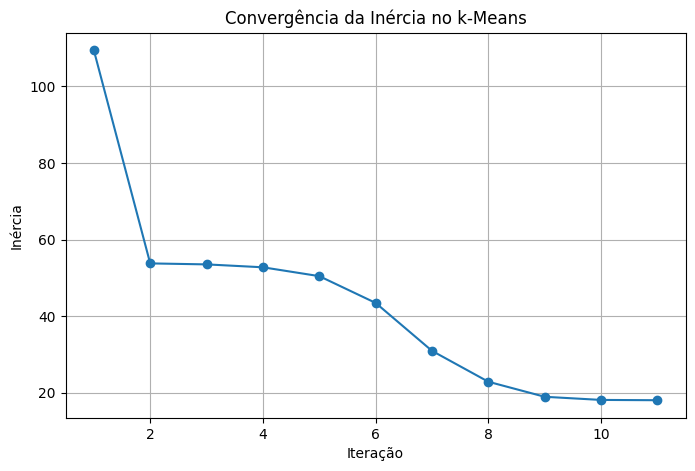

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(historico_inercia) + 1),
    historico_inercia,
    marker="o"
)

plt.xlabel("Iteração")
plt.ylabel("Inércia")
plt.title("Convergência da Inércia no k-Means")
plt.grid(True)

plt.show()

Executrando o k-Means para k = [1, 2, 3, 4, 5]

In [33]:
valores_k = [1, 2, 3, 4, 5]

inercia_final = []

for k_atual in valores_k:
    torch.manual_seed(42)

    _, _, historico = kmeans(
        X2_t,
        k=k_atual
    )
    inercia_final.append(historico[-1])

tabela_cotovelo = pd.DataFrame({
    "k": valores_k,
    "Inércia final": inercia_final
})

tabela_cotovelo

Convergência alcançada na iteração 2
Convergência alcançada na iteração 2
Convergência alcançada na iteração 11
Convergência alcançada na iteração 6
Convergência alcançada na iteração 11


,k,Inércia final
0,1,300.000000
1,2,54.168766
2,3,18.026951
3,4,17.320652
4,5,11.825465


Gerando o grafico cotovelo

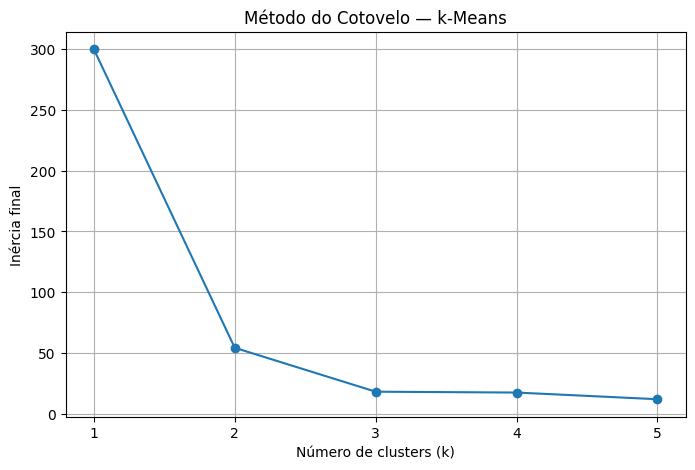

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabela_cotovelo["k"],
    tabela_cotovelo["Inércia final"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia final")
plt.title("Método do Cotovelo — k-Means")
plt.xticks(valores_k)
plt.grid(True)

plt.show()

Visualizando os clusters

Convergência alcançada na iteração 11


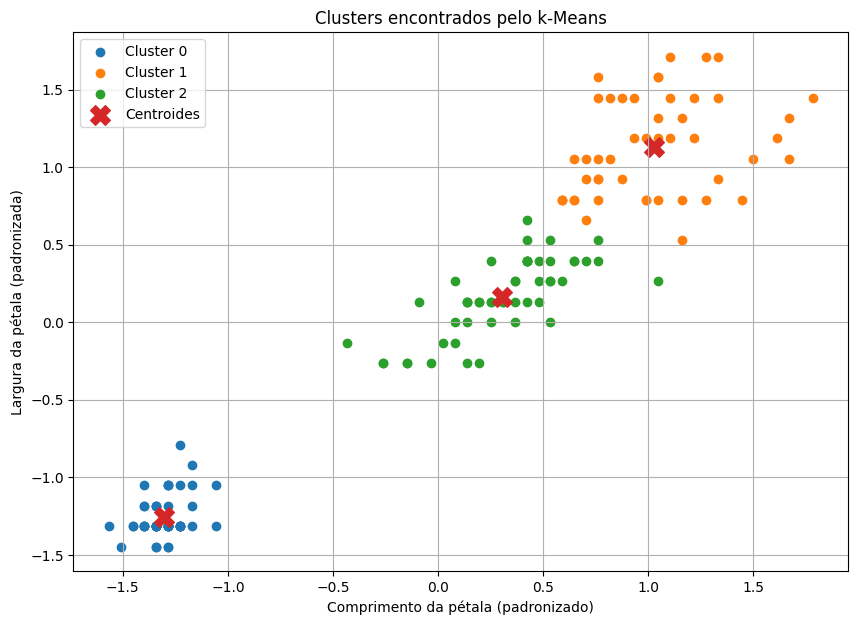

In [36]:
torch.manual_seed(42)

clusters_kmeans, centroides_finais, historico_inercia = kmeans(
    X2_t,
    k=3
)
clusters_np = clusters_kmeans.cpu().numpy()
centroides_np = centroides_finais.cpu().numpy()

plt.figure(figsize=(10, 7))

for i in range(3):
    pontos = X2[clusters_np == i]

    plt.scatter(
        pontos[:, 0],
        pontos[:, 1],
        label=f"Cluster {i}"
    )

plt.scatter(
    centroides_np[:, 0],
    centroides_np[:, 1],
    marker="X",
    s=200,
    label="Centroides"
)

plt.xlabel("Comprimento da pétala (padronizado)")
plt.ylabel("Largura da pétala (padronizada)")
plt.title("Clusters encontrados pelo k-Means")
plt.legend()
plt.grid(True)

plt.show()

Comparando os clusters com as espécies

In [37]:
cluster_para_classe = {}

for cluster in range(3):
    labels_cluster = y[clusters_np == cluster]

    contagem = np.bincount(labels_cluster, minlength=3)

    classe_mais_comum = np.argmax(contagem)

    cluster_para_classe[cluster] = classe_mais_comum

    print(
        f"Cluster {cluster} -> "
        f"{nomes[classe_mais_comum]}"
    )

Cluster 0 -> setosa
Cluster 1 -> virginica
Cluster 2 -> versicolor


Calculando a acurácia do k-Means

In [38]:
predicoes_kmeans = np.array([
    cluster_para_classe[cluster]
    for cluster in clusters_np
])

acuracia_kmeans = np.mean(
    predicoes_kmeans == y
)

print(
    f"Acurácia do k-Means: "
    f"{acuracia_kmeans:.4f}"
)

Acurácia do k-Means: 0.9600


Exercicios 3

Calculando a de distâncias do DBSCAN

In [39]:
distancias_dbscan = torch.cdist(X2_t, X2_t)

print("Formato da matriz de distâncias:")
print(distancias_dbscan.shape)

Formato da matriz de distâncias:
torch.Size([150, 150])


Criando a vizinhança

In [40]:
eps = 0.5
min_pts = 8

vizinhos = distancias_dbscan <= eps

print("Formato da máscara:", vizinhos.shape)
print("Tipo:", vizinhos.dtype)

Formato da máscara: torch.Size([150, 150])
Tipo: torch.bool


Encontrando os pontos núcleo

In [41]:
quantidade_vizinhos = vizinhos.sum(dim=1)

pontos_nucleo = quantidade_vizinhos >= min_pts

print("Quantidade de pontos núcleo:",
      pontos_nucleo.sum().item())

print("\nQuantidade de vizinhos dos primeiros 10 pontos:")
print(quantidade_vizinhos[:10])

Quantidade de pontos núcleo: 149

Quantidade de vizinhos dos primeiros 10 pontos:
tensor([49, 49, 49, 49, 49, 49, 50, 49, 49, 48])


Verificando os pontos núcleo

In [42]:
print(
    f"Pontos núcleo: {pontos_nucleo.sum().item()} "
    f"de {X2_t.shape[0]}"
)

print(
    f"Pontos que não são núcleo: "
    f"{(~pontos_nucleo).sum().item()}"
)

Pontos núcleo: 149 de 150
Pontos que não são núcleo: 1


Implementando a expanção dos clusters

In [43]:
def dbscan(X, eps=0.5, min_pts=8):

    n = X.shape[0]

    distancias = torch.cdist(X, X)

    vizinhos = distancias <= eps

    quantidade_vizinhos = vizinhos.sum(dim=1)

    pontos_nucleo = quantidade_vizinhos >= min_pts

    for ponto_inicial in range(n):

        if clusters[ponto_inicial] != -1:
            continue

        if not pontos_nucleo[ponto_inicial]:
            continue

        clusters[ponto_inicial] = cluster_atual

        fila = torch.where(
            vizinhos[ponto_inicial]
        )[0].tolist()

        indice_fila = 0

        while indice_fila < len(fila):

            ponto = fila[indice_fila]
            indice_fila += 1

            if clusters[ponto] == -1:
                clusters[ponto] = cluster_atual

            if pontos_nucleo[ponto]:

                novos_vizinhos = torch.where(
                    vizinhos[ponto]
                )[0].tolist()

                for vizinho in novos_vizinhos:

                    if vizinho not in fila:
                        fila.append(vizinho)

                    if clusters[vizinho] == -1:
                        clusters[vizinho] = cluster_atual

        cluster_atual += 1

    return clusters, pontos_nucleo

Executando o DBSCAN

In [44]:
eps = 0.5
min_pts = 8

clusters_dbscan, pontos_nucleo = dbscan(
    X2_t,
    eps=eps,
    min_pts=min_pts
)

print("Clusters encontrados:")
print(clusters_dbscan)

Clusters encontrados:
tensor([0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2,
        2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0,
        2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1])


Contando os grupos e ruídos

In [45]:
clusters_unicos = torch.unique(clusters_dbscan)

clusters_sem_ruido = clusters_unicos[
    clusters_unicos != -1
]

quantidade_clusters = len(clusters_sem_ruido)

quantidade_ruido = (
    clusters_dbscan == -1
).sum().item()

print("Quantidade de clusters:", quantidade_clusters)
print("Quantidade de pontos de ruído:", quantidade_ruido)

Quantidade de clusters: 3
Quantidade de pontos de ruído: 0


Verificando quandos pontos tem em cada grupo

In [46]:
print("Quantidade de pontos por cluster:")

for cluster in clusters_sem_ruido:
    cluster_int = cluster.item()

    quantidade = (
        clusters_dbscan == cluster_int
    ).sum().item()

    print(
        f"Cluster {cluster_int}: "
        f"{quantidade} pontos"
    )

print(f"Ruído: {quantidade_ruido} pontos")

Quantidade de pontos por cluster:
Cluster 0: 24 pontos
Cluster 1: 100 pontos
Cluster 2: 26 pontos
Ruído: 0 pontos


Visualizando o DBSCAM

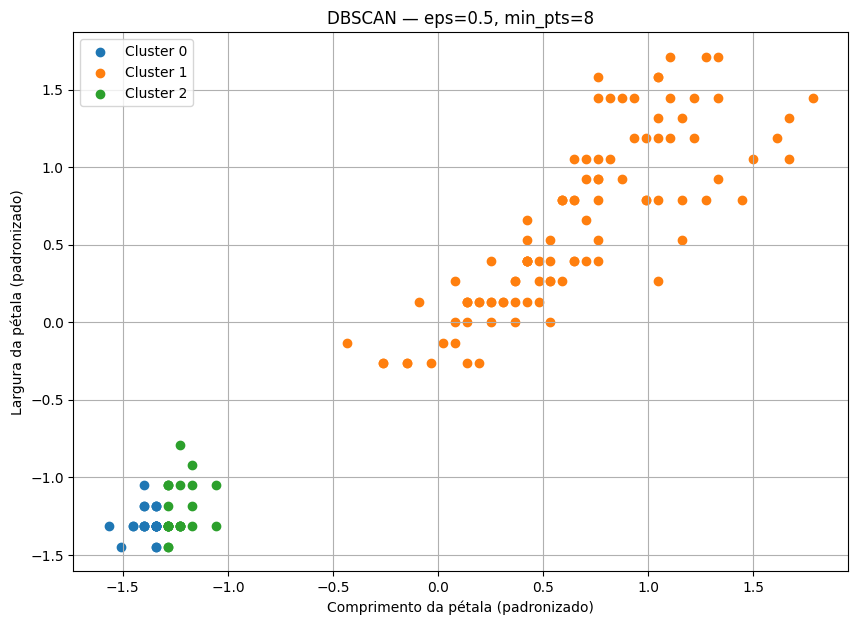

In [47]:
clusters_np = clusters_dbscan.cpu().numpy()

plt.figure(figsize=(10, 7))

for cluster in sorted(set(clusters_np)):

    pontos = X2[clusters_np == cluster]

    if cluster == -1:
        plt.scatter(
            pontos[:, 0],
            pontos[:, 1],
            marker="x",
            s=80,
            label="Ruído"
        )
    else:
        plt.scatter(
            pontos[:, 0],
            pontos[:, 1],
            label=f"Cluster {cluster}"
        )

plt.xlabel("Comprimento da pétala (padronizado)")
plt.ylabel("Largura da pétala (padronizado)")
plt.title(
    f"DBSCAN — eps={eps}, min_pts={min_pts}"
)
plt.legend()
plt.grid(True)

plt.show()

Testando os eps para eps = [0.2, 0.5, 0.8, 1.0]

In [48]:
valores_eps = [0.2, 0.5, 0.8, 1.0]

resultados_dbscan = {}

for eps_atual in valores_eps:

    clusters, nucleos = dbscan(
        X2_t,
        eps=eps_atual,
        min_pts=8
    )

    resultados_dbscan[eps_atual] = clusters

    clusters_unicos = torch.unique(clusters)

    clusters_sem_ruido = clusters_unicos[
        clusters_unicos != -1
    ]

    quantidade_clusters = len(
        clusters_sem_ruido
    )

    quantidade_ruido = (
        clusters == -1
    ).sum().item()

    print(
        f"eps = {eps_atual}: "
        f"{quantidade_clusters} clusters, "
        f"{quantidade_ruido} pontos de ruído"
    )

eps = 0.2: 3 clusters, 0 pontos de ruído
eps = 0.5: 3 clusters, 0 pontos de ruído
eps = 0.8: 3 clusters, 0 pontos de ruído
eps = 1.0: 3 clusters, 0 pontos de ruído


Visualizando so quadro resultados


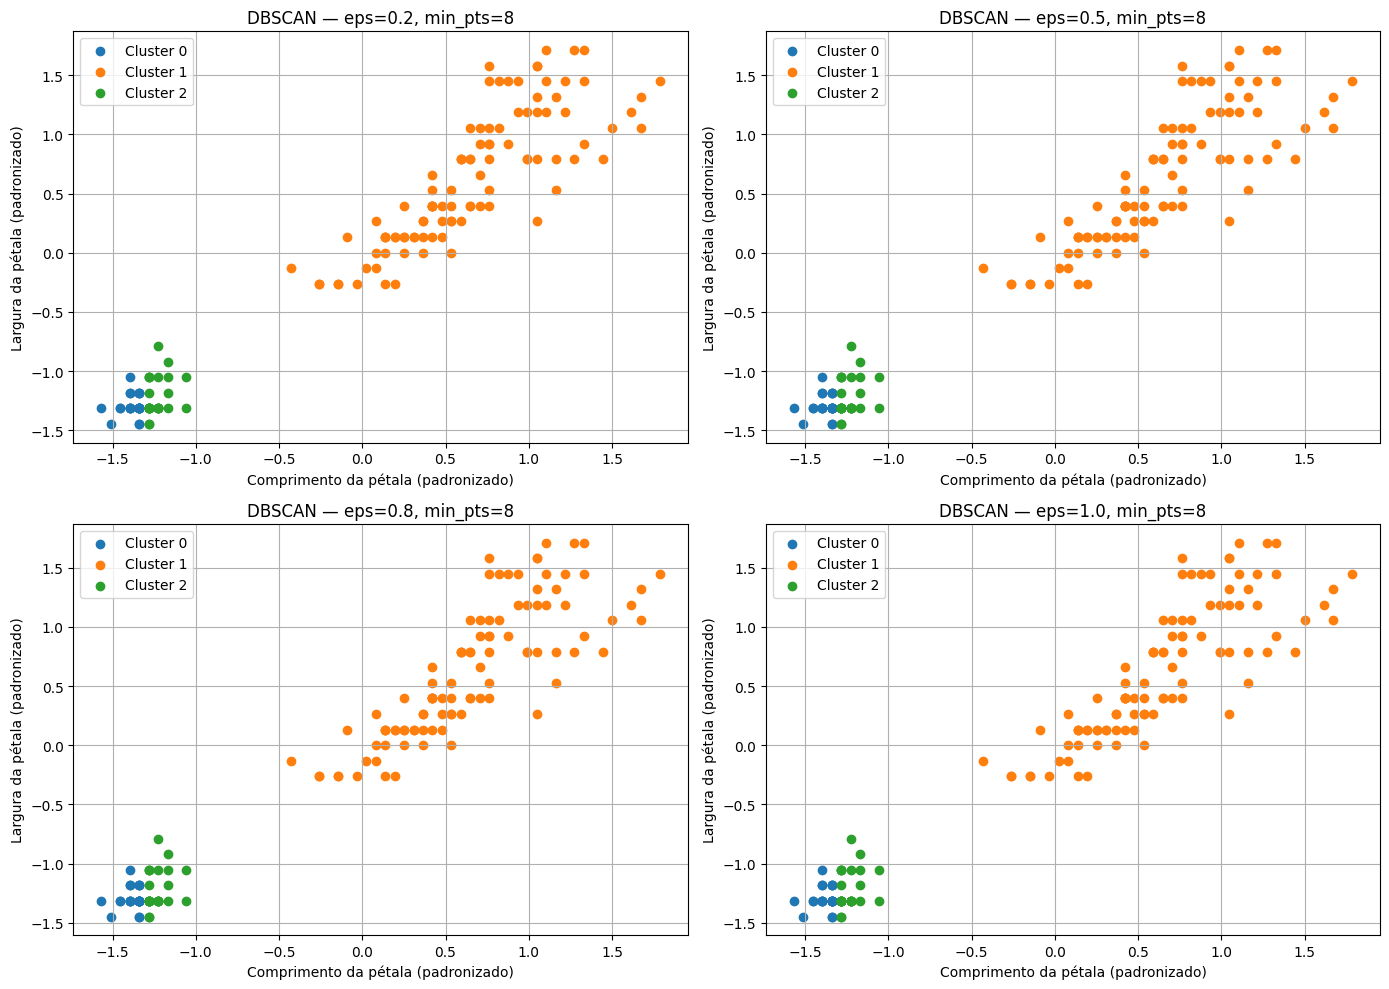

In [49]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for ax, eps_atual in zip(
    axes.ravel(),
    valores_eps
):

    clusters = resultados_dbscan[eps_atual]
    clusters_np = clusters.cpu().numpy()

    for cluster in sorted(set(clusters_np)):

        pontos = X2[
            clusters_np == cluster
        ]

        if cluster == -1:

            ax.scatter(
                pontos[:, 0],
                pontos[:, 1],
                marker="x",
                s=60,
                label="Ruído"
            )

        else:

            ax.scatter(
                pontos[:, 0],
                pontos[:, 1],
                label=f"Cluster {cluster}"
            )

    ax.set_xlabel(
        "Comprimento da pétala (padronizado)"
    )

    ax.set_ylabel(
        "Largura da pétala (padronizado)"
    )

    ax.set_title(
        f"DBSCAN — eps={eps_atual}, min_pts=8"
    )

    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

Comparativo Final

k-NN

O k-NN apresentou uma acurácia de 93,33% com k = 5.
O método utiliza os rótulos dos dados de treinamento para classificar
novos exemplos com base nos vizinhos mais próximos.

k-Means

O k-Means apresentou uma acurácia de 96,00% após associarmos cada
cluster à espécie mais frequente dentro dele. O método não utiliza
os rótulos durante a formação dos grupos, sendo portanto uma técnica
não supervisionada.

O método do cotovelo indicou que k = 3 é uma escolha adequada para
a base Iris, pois após esse valor a redução da inércia se torna menor.

DBSCAN

Com eps = 0.5 e min_pts = 8, o DBSCAN encontrou 3 clusters e
nenhum ponto de ruído. Na análise de sensibilidade, os valores
eps = 0.2, 0.5, 0.8 e 1.0 também produziram 3 clusters e 0 pontos
de ruído.

Comparação

Neste experimento, o k-Means apresentou a maior acurácia entre os
resultados avaliados, com 96,00%, enquanto o k-NN apresentou 93,33%.

Entretanto, os dois métodos possuem objetivos diferentes. O k-NN é
um método supervisionado, enquanto o k-Means realiza agrupamento
sem utilizar os rótulos das espécies.

O DBSCAN é especialmente interessante quando não sabemos previamente
quantos grupos existem e quando queremos identificar grupos com base
na densidade dos dados e também detectar possíveis pontos de ruído.